In [2]:
import os
import json
from pathlib import Path

import pandas as pd
import numpy as np
from tensorflow.keras import layers, models
import tensorflow as tf
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [3]:

DATA_DIR = Path("../data/processed/augmented")
FIGURE_DIR = '../outputs/figures'
PLOTS_DIR = '../outputs/figures/plots'
MODEL_DIR = Path("../outputs/models")
OUTPUT_DIR = Path("../outputs")
EVAL_DIR = Path("../outputs/predictions")

ACTIVE_STAGE = "stage05"

SIZE_ORDER = ["edgeLarge", "giants", "large", "medium", "small", "tiny"]
METRICS = ["object_recall", "pixel_recall", "mean_coverage"]

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)


In [4]:
# run perClassEvaluation.ipynb notebook twice with the same ACTIVE_STAGE - once with MODEL_TAG = "bubble_baseline"`, once with
# MODEL_TAG = "bubble_baseline"`


UNET_EVAL = EVAL_DIR / f"{ACTIVE_STAGE}perClassEval.csv"
BASELINE_EVAL = EVAL_DIR / f"{ACTIVE_STAGE}baseline_perClassEval.csv"

for path in (UNET_EVAL, BASELINE_EVAL):
    assert path.exists(), (
        f"{path} missing - run perClassEvaluation.ipynb with the matching MODEL_TAG"
    )

unet = pd.read_csv(UNET_EVAL, index_col=0).reindex(SIZE_ORDER).dropna(how="all")
baseline = pd.read_csv(BASELINE_EVAL, index_col=0).reindex(SIZE_ORDER).dropna(how="all")

model_comparison = pd.DataFrame(index=unet.index)
model_comparison["n_bubbles"] = unet["n_bubbles"].astype(int)
for m in METRICS:
    model_comparison[f"{m}_unet"] = unet[m]
    model_comparison[f"{m}_baseline"] = baseline[m]
    model_comparison[f"{m}_delta"] = unet[m] - baseline[m]

print("global precision  unet:", round(unet["global_precision"].iloc[0], 3),
      "| baseline:", round(baseline["global_precision"].iloc[0], 3))
print("predicted blobs   unet:", int(unet["global_n_pred_blobs"].iloc[0]),
      f"({int(unet['global_n_spurious'].iloc[0])} spurious)",
      "| baseline:", int(baseline["global_n_pred_blobs"].iloc[0]),
      f"({int(baseline['global_n_spurious'].iloc[0])} spurious)")

model_comparison.to_csv(EVAL_DIR / f"{ACTIVE_STAGE}modelComparison.csv")
model_comparison.round(3)


global precision  unet: 0.737 | baseline: 0.537
predicted blobs   unet: 133 (35 spurious) | baseline: 523 (242 spurious)


,n_bubbles,object_recall_unet,object_recall_baseline,object_recall_delta,pixel_recall_unet,pixel_recall_baseline,pixel_recall_delta,mean_coverage_unet,mean_coverage_baseline,mean_coverage_delta
size_class,,,,,,,,,,
edgeLarge,26,0.615,0.231,0.385,0.622,0.332,0.290,0.620,0.349,0.271
giants,157,0.573,0.580,-0.006,0.582,0.496,0.086,0.578,0.548,0.030
large,155,0.613,0.800,-0.187,0.598,0.767,-0.169,0.593,0.759,-0.166
medium,95,0.611,0.621,-0.011,0.580,0.615,-0.036,0.566,0.612,-0.046
small,75,0.533,0.533,0.000,0.527,0.525,0.002,0.519,0.512,0.007
tiny,53,0.698,0.528,0.170,0.696,0.602,0.095,0.667,0.516,0.151


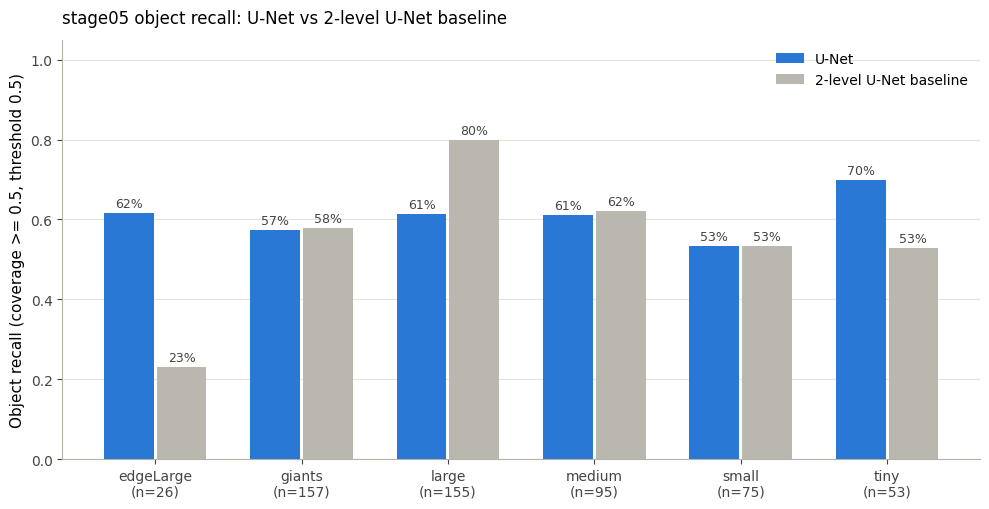

In [5]:
# object recall per size class: U-Net vs 2-level U-Net baseline
# color follows the model (blue = U-Net, recessive gray = baseline),
# same pairing as the chance-floor dumbbell plot

MODEL_COLORS = {"U-Net": "#2a78d6", "2-level U-Net baseline": "#b9b7ae"}
INK = "#444441"

classes = model_comparison.index.tolist()
xs = np.arange(len(classes))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 5.2))
for k, (name, series) in enumerate([("U-Net", unet["object_recall"]),
                                    ("2-level U-Net baseline", baseline["object_recall"])]):
    offsets = xs + (k - 0.5) * (width + 0.02)
    ax.bar(offsets, series.values, width=width,
           color=MODEL_COLORS[name], label=name, zorder=3)
    for x, v in zip(offsets, series.values):
        ax.text(x, v + 0.015, f"{v:.0%}", ha="center", fontsize=9, color=INK)

ax.set_xticks(xs)
ax.set_xticklabels([f"{c}\n(n={int(model_comparison.loc[c, 'n_bubbles'])})"
                    for c in classes], fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Object recall (coverage >= 0.5, threshold 0.5)", fontsize=11)
ax.set_title(f"{ACTIVE_STAGE} object recall: U-Net vs 2-level U-Net baseline",
             fontsize=12, loc="left", pad=12)
ax.legend(frameon=False, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#b4b2a9")
ax.tick_params(colors=INK)
ax.grid(axis="y", color="#e6e4dc", lw=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f"{ACTIVE_STAGE}baselineComparison.png"),
            dpi=300, bbox_inches="tight")
plt.show()
